In [36]:
import numpy as np
import torch
from matplotlib import pylab as plt
import torch.nn as nn 
import torch.nn.functional as F
import random

In [3]:
# environment
import sys
sys.path.append("../")

In [5]:
from envs.gridworld.Gridworld import Gridworld
from IPython.display import clear_output

In [31]:
env = Gridworld(size=4, mode='static')
env.display()

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [32]:
env.makeMove('d')
env.makeMove('d')
env.makeMove('l')
env.makeMove('l')
env.makeMove('l')
env.makeMove('l')
env.makeMove('u')
env.makeMove('u')
env.display()

array([['+', '-', ' ', ' '],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [33]:
env.reward()

10

In [35]:
env.board.render_np() # player, goal, pit, wall

array([[[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [40]:
env.board.render_np().shape #frames x height x width

(4, 4, 4)

In [44]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### The Gridworld Network: Main QNetwork and Target QNetwork

In [55]:
class Network(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super().__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.hidden_size = hidden_size
        self.layer1 = nn.Linear(self.state_size, 150)
        self.layer2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.output = nn.Linear(self.hidden_size, self.action_size)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.output(x)

### The Gridworld Agent

In [ ]:
from collections import deque

class GridWorldAgent:
    ACTION_SET = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}

    def __init__(self, state_size, action_size, hidden_size, lr, buffer_size=1000):
        self.state_size = state_size
        self.action_size = action_size

        self.main_network = Network(state_size, action_size, hidden_size).to(device)
        self.target_network = Network(state_size, action_size, hidden_size).to(device)
        self.target_network.load_state_dict(self.main_network.state_dict())
        self.target_network.eval()

        self.optimizer = torch.optim.Adam(self.main_network.parameters(), lr=lr)  
        self.memory = deque(maxlen=buffer_size)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def select_action(self, state, epsilon):
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.randint(0, self.action_size)              # explore
        else:
            with torch.no_grad():
                q_values = self.main_network(state.to(device))          
                action = torch.argmax(q_values, dim=1).item()            # exploit
        return action   

    def train(self, gamma, batch_size):
        if len(self.memory) < batch_size:
            return None

        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.cat(states).to(device)
        next_states = torch.cat(next_states).to(device)
        actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)

        q_values = self.main_network(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0]
            target = rewards + gamma * next_q * (1 - dones)

        loss = F.mse_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self, num_iter, update_rate):
        if num_iter % update_rate == 0:
            self.target_network.load_state_dict(self.main_network.state_dict())

### Training Loop

In [ ]:
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.01
num_episodes = 1000
epsilon_decay_steps = num_episodes * 0.15
epsilon_decay = (epsilon_start - epsilon_min) / epsilon_decay_steps
lr = 1e-3
batch_size = 32
update_rate = 50   # sync target network every 50 steps

in_dim = 4 * 4 * 4
out_dim = 4
h_dim = 150
agent = GridWorldAgent(in_dim, out_dim, h_dim, lr)

losses = []
stats_rewards_list = []
epsilon = epsilon_start
num_iter = 0

for ep in range(num_episodes):
    env = Gridworld(size=4, mode='random')
    state_ = env.board.render_np().reshape(-1, 64) + np.random.rand(1, 64) / 10.0
    state = torch.from_numpy(state_).float()

    episode_loss = []
    total_reward = 0
    status = 1

    while status == 1:
        action = agent.select_action(state, epsilon)
        env.makeMove(agent.ACTION_SET[action])

        next_state_ = env.board.render_np().reshape(-1, 64) + np.random.rand(1, 64) / 10.0 #relu stability
        next_state = torch.from_numpy(next_state_).float()
        reward = env.reward()
        done = 1 if reward != -1 else 0

        agent.remember(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward
        epsilon = max(epsilon_min, epsilon - epsilon_decay)

        loss = agent.train(gamma, batch_size)
        if loss is not None:
            episode_loss.append(loss)
            if num_iter % 10 == 0:
                print(f"Episode {ep:4d} | Iter {num_iter:6d} | Loss: {loss:.4f} | Epsilon: {epsilon:.3f}")

        agent.update_target_network(num_iter, update_rate)
        num_iter += 1

        if done:
            status = 0

    losses.append(np.mean(episode_loss) if episode_loss else np.nan)
    stats_rewards_list.append(total_reward)

Episode    3 | Iter     40 | Loss: 6.7285 | Epsilon: 0.729
Episode    4 | Iter     50 | Loss: 6.5799 | Epsilon: 0.663
Episode    4 | Iter     60 | Loss: 2.8471 | Epsilon: 0.597
Episode    4 | Iter     70 | Loss: 7.0546 | Epsilon: 0.531
Episode    4 | Iter     80 | Loss: 4.3151 | Epsilon: 0.465
Episode    4 | Iter     90 | Loss: 3.0123 | Epsilon: 0.399
Episode    4 | Iter    100 | Loss: 3.9138 | Epsilon: 0.333
Episode    4 | Iter    110 | Loss: 3.9545 | Epsilon: 0.267
Episode    4 | Iter    120 | Loss: 0.2054 | Epsilon: 0.201
Episode    5 | Iter    130 | Loss: 0.3807 | Epsilon: 0.135
Episode    5 | Iter    140 | Loss: 0.4451 | Epsilon: 0.069
Episode    5 | Iter    150 | Loss: 0.4766 | Epsilon: 0.010
Episode    5 | Iter    160 | Loss: 2.8568 | Epsilon: 0.010
Episode    6 | Iter    170 | Loss: 1.2214 | Epsilon: 0.010
Episode    6 | Iter    180 | Loss: 0.2341 | Epsilon: 0.010
Episode    6 | Iter    190 | Loss: 2.3602 | Epsilon: 0.010
Episode    6 | Iter    200 | Loss: 0.1547 | Epsilon: 0.0

### Loss and Reward plots over num_episodes episodes

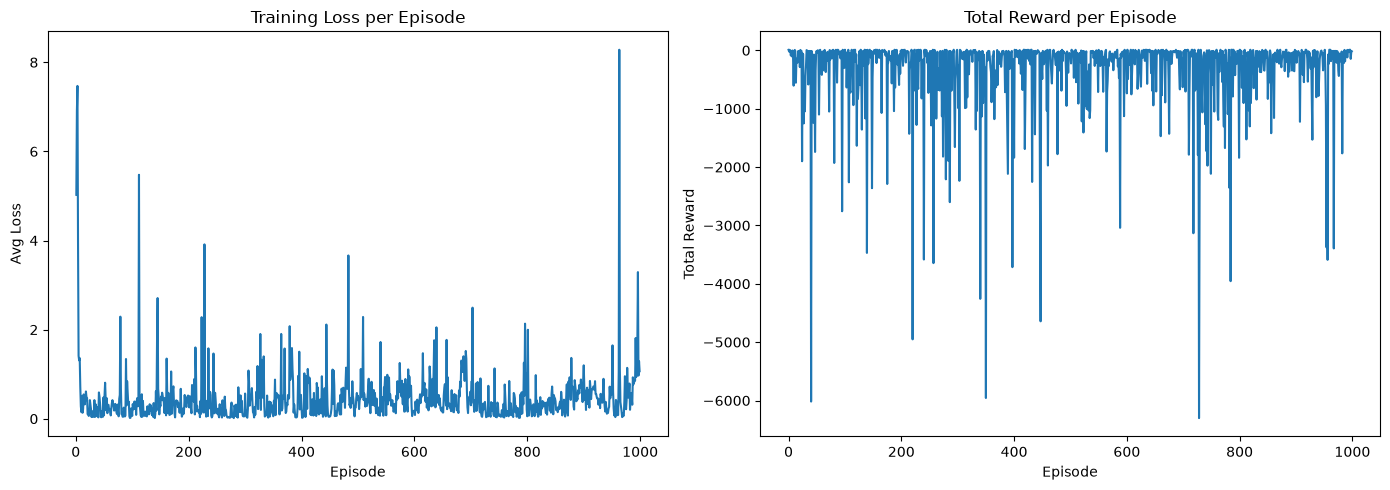

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(losses)
axes[0].set_title("Training Loss per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg Loss")


axes[1].plot(stats_rewards_list)
axes[1].set_title("Total Reward per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward")

plt.tight_layout()
plt.show()

### Testing the Agent

In [66]:
def test_agent(agent, mode='static', display=True):
    i = 0
    test_env = Gridworld(mode=mode)
    state_ = env.board.render_np().reshape(-1, 64) + np.random.rand(1, 64) / 10.0
    state = torch.from_numpy(state_).float()

    if display:
        print('Initial State: ')
        print(test_env.display())
    status = 1

    while(status == 1):
        action_idx = agent.select_action(state, epsilon)
        action = agent.ACTION_SET[action_idx]
        if display:
            print(f'Move #: {i}; Taking action: {action}')
        env.makeMove(action)
        state_ = env.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state = torch.from_numpy(state_).float()
        if display:
            print(env.display())
        reward = env.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print(f'Game won! Reward: {reward}')
            else:
                status = 0
                if display:
                    print(f'Game LOST. Reward: {reward}')
        i += 1
        if (i > 15):
            if display:
                print(f'Game lost; too many moves.')
            break

    win = True if status == 2 else False
    return win
    

In [67]:
test_agent(agent, 'random')

Initial State: 
[['+' ' ' ' ' '-']
 [' ' ' ' ' ' 'P']
 [' ' ' ' ' ' ' ']
 [' ' ' ' 'W' ' ']]
Move #: 0; Taking action: d
[[' ' ' ' '+' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']
 ['W' ' ' '-' ' ']]
Move #: 1; Taking action: l
[[' ' ' ' '+' ' ']
 [' ' 'P' ' ' ' ']
 [' ' ' ' ' ' ' ']
 ['W' ' ' '-' ' ']]
Move #: 2; Taking action: u
[[' ' 'P' '+' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 ['W' ' ' '-' ' ']]
Move #: 3; Taking action: r
[[' ' ' ' '+' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 ['W' ' ' '-' ' ']]
Game won! Reward: 10


True

### Static Environment

- Exponential epsilon decay
- Max steps specified

In [75]:
gamma = 0.9

epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay_rate = 5000

num_episodes = 1000
max_steps = 100

lr = 1e-3
batch_size = 32
update_rate = 50

in_dim = 4 * 4 * 4
out_dim = 4
h_dim = 150

agent = GridWorldAgent(
    in_dim,
    out_dim,
    h_dim,
    lr
)

losses = []
stats_rewards_list = []

num_iter = 0


for ep in range(num_episodes):

    env = Gridworld(size=4, mode='static')

    
    state_ = (
        env.board.render_np().reshape(-1, 64)
        + np.random.rand(1, 64) / 10.0
    )

    state = torch.from_numpy(state_).float()

    episode_loss = []
    total_reward = 0

    
    for step in range(max_steps):
        epsilon = epsilon_min + (
            epsilon_start - epsilon_min
        ) * np.exp(-num_iter / epsilon_decay_rate)

    
        action = agent.select_action(
            state,
            epsilon
        )

        env.makeMove(
            agent.ACTION_SET[action]
        )

    
        next_state_ = (
            env.board.render_np().reshape(-1, 64)
            + np.random.rand(1, 64) / 10.0
        )

        next_state = torch.from_numpy(
            next_state_
        ).float()

        
        reward = env.reward()

       
        done = 1 if reward != -1 else 0

       
        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        
        state = next_state

        total_reward += reward

       
        loss = agent.train(
            gamma,
            batch_size
        )

        if loss is not None:

            episode_loss.append(loss)

            if num_iter % 10 == 0:

                print(
                    f"Episode {ep:4d} | "
                    f"Step {step:3d} | "
                    f"Iter {num_iter:6d} | "
                    f"Loss: {loss:.4f} | "
                    f"Epsilon: {epsilon:.3f}"
                )

       
        agent.update_target_network(
            num_iter,
            update_rate
        )

        num_iter += 1

       
        if done:
            break

    losses.append(
        np.mean(episode_loss)
        if episode_loss
        else np.nan
    )

    stats_rewards_list.append(
        total_reward
    )

Episode    1 | Step  25 | Iter     40 | Loss: 3.2748 | Epsilon: 0.992
Episode    1 | Step  35 | Iter     50 | Loss: 2.3986 | Epsilon: 0.990
Episode    1 | Step  45 | Iter     60 | Loss: 0.3633 | Epsilon: 0.988
Episode    2 | Step   8 | Iter     70 | Loss: 5.3795 | Epsilon: 0.986
Episode    3 | Step   9 | Iter     80 | Loss: 2.9120 | Epsilon: 0.984
Episode    5 | Step   3 | Iter     90 | Loss: 2.3179 | Epsilon: 0.982
Episode    5 | Step  13 | Iter    100 | Loss: 2.6377 | Epsilon: 0.980
Episode    6 | Step   8 | Iter    110 | Loss: 5.7328 | Epsilon: 0.978
Episode    6 | Step  18 | Iter    120 | Loss: 0.6074 | Epsilon: 0.977
Episode    6 | Step  28 | Iter    130 | Loss: 0.3003 | Epsilon: 0.975
Episode    7 | Step   3 | Iter    140 | Loss: 0.1375 | Epsilon: 0.973
Episode    8 | Step   7 | Iter    150 | Loss: 0.0814 | Epsilon: 0.971
Episode    8 | Step  17 | Iter    160 | Loss: 0.1318 | Epsilon: 0.969
Episode    8 | Step  27 | Iter    170 | Loss: 0.0428 | Epsilon: 0.967
Episode    9 | Step 

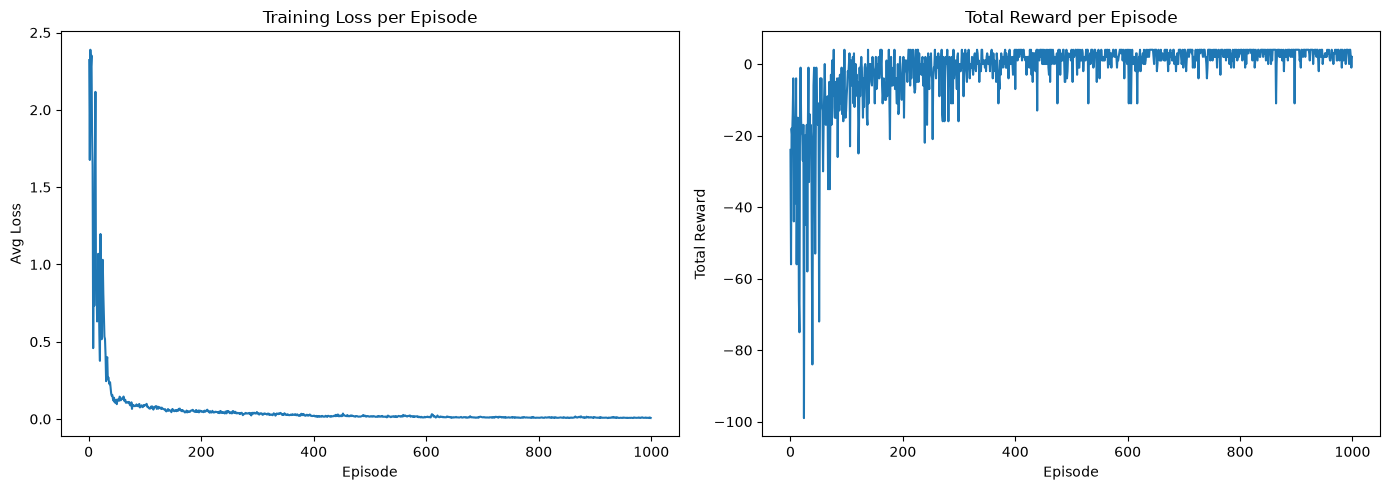

In [76]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(losses)
axes[0].set_title("Training Loss per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg Loss")


axes[1].plot(stats_rewards_list)
axes[1].set_title("Total Reward per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward")

plt.tight_layout()
plt.show()

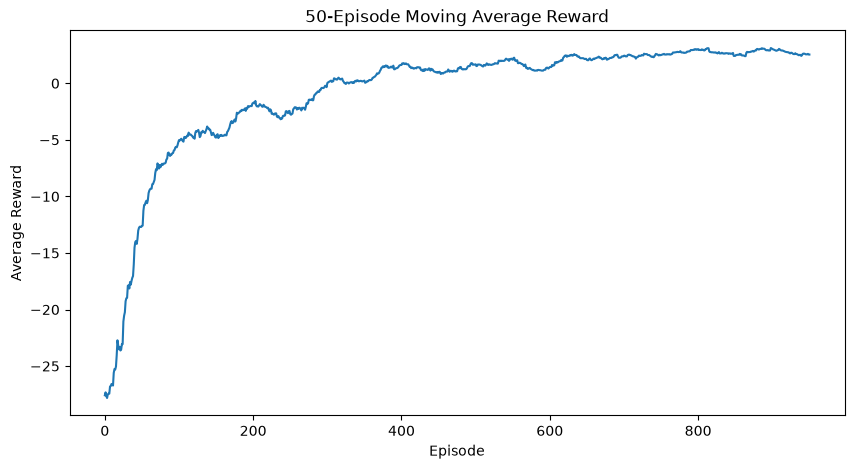

In [77]:
window = 50

reward_moving_avg = np.convolve(
    stats_rewards_list,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(reward_moving_avg)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("50-Episode Moving Average Reward")

plt.show()

In [78]:
test_agent(agent, 'static')

Initial State: 
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Move #: 0; Taking action: u
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
Game won! Reward: 10


True

### Random Environment

- Exponential epsilon decay
- Max steps specified

In [79]:
gamma = 0.9

epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay_rate = 5000

num_episodes = 1000
max_steps = 100

lr = 1e-3
batch_size = 32
update_rate = 50

in_dim = 4 * 4 * 4
out_dim = 4
h_dim = 150

agent = GridWorldAgent(
    in_dim,
    out_dim,
    h_dim,
    lr
)

losses = []
stats_rewards_list = []

num_iter = 0


for ep in range(num_episodes):

    env = Gridworld(size=4, mode='random')

    
    state_ = (
        env.board.render_np().reshape(-1, 64)
        + np.random.rand(1, 64) / 10.0
    )

    state = torch.from_numpy(state_).float()

    episode_loss = []
    total_reward = 0

    
    for step in range(max_steps):
        epsilon = epsilon_min + (
            epsilon_start - epsilon_min
        ) * np.exp(-num_iter / epsilon_decay_rate)

    
        action = agent.select_action(
            state,
            epsilon
        )

        env.makeMove(
            agent.ACTION_SET[action]
        )

    
        next_state_ = (
            env.board.render_np().reshape(-1, 64)
            + np.random.rand(1, 64) / 10.0
        )

        next_state = torch.from_numpy(
            next_state_
        ).float()

        
        reward = env.reward()

       
        done = 1 if reward != -1 else 0

       
        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        
        state = next_state

        total_reward += reward

       
        loss = agent.train(
            gamma,
            batch_size
        )

        if loss is not None:

            episode_loss.append(loss)

            if num_iter % 10 == 0:

                print(
                    f"Episode {ep:4d} | "
                    f"Step {step:3d} | "
                    f"Iter {num_iter:6d} | "
                    f"Loss: {loss:.4f} | "
                    f"Epsilon: {epsilon:.3f}"
                )

       
        agent.update_target_network(
            num_iter,
            update_rate
        )

        num_iter += 1

       
        if done:
            break

    losses.append(
        np.mean(episode_loss)
        if episode_loss
        else np.nan
    )

    stats_rewards_list.append(
        total_reward
    )

Episode    0 | Step  40 | Iter     40 | Loss: 0.5284 | Epsilon: 0.992
Episode    2 | Step   4 | Iter     50 | Loss: 3.3976 | Epsilon: 0.990
Episode    2 | Step  14 | Iter     60 | Loss: 3.8336 | Epsilon: 0.988
Episode    3 | Step   8 | Iter     70 | Loss: 6.5954 | Epsilon: 0.986
Episode    3 | Step  18 | Iter     80 | Loss: 9.7395 | Epsilon: 0.984
Episode    3 | Step  28 | Iter     90 | Loss: 5.8203 | Epsilon: 0.982
Episode    5 | Step   4 | Iter    100 | Loss: 3.8449 | Epsilon: 0.980
Episode    7 | Step   0 | Iter    110 | Loss: 8.1605 | Epsilon: 0.978
Episode    7 | Step  10 | Iter    120 | Loss: 11.9225 | Epsilon: 0.977
Episode    7 | Step  20 | Iter    130 | Loss: 8.3050 | Epsilon: 0.975
Episode    7 | Step  30 | Iter    140 | Loss: 3.4846 | Epsilon: 0.973
Episode    7 | Step  40 | Iter    150 | Loss: 2.5349 | Epsilon: 0.971
Episode    7 | Step  50 | Iter    160 | Loss: 4.6505 | Epsilon: 0.969
Episode    7 | Step  60 | Iter    170 | Loss: 3.5489 | Epsilon: 0.967
Episode    8 | Step

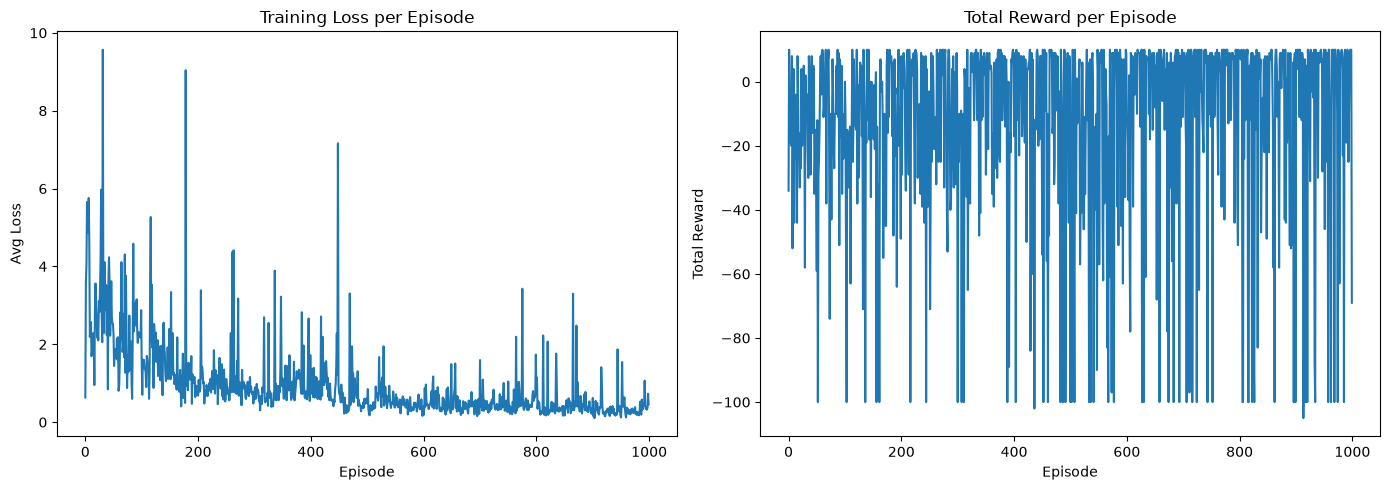

In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(losses)
axes[0].set_title("Training Loss per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg Loss")


axes[1].plot(stats_rewards_list)
axes[1].set_title("Total Reward per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward")

plt.tight_layout()
plt.show()

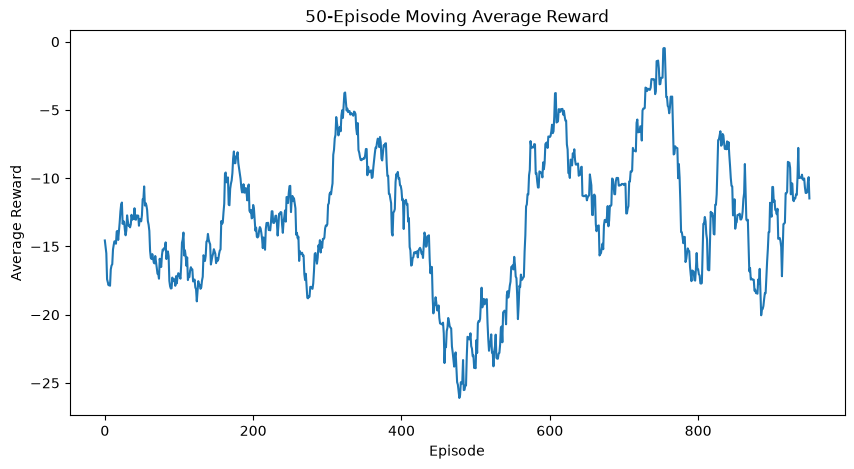

In [81]:
window = 50

reward_moving_avg = np.convolve(
    stats_rewards_list,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(reward_moving_avg)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("50-Episode Moving Average Reward")

plt.show()

### Tweeking Hyperparmaters 1

In [82]:
gamma = 0.9

epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay_rate = 5000

num_episodes = 3000
max_steps = 100

lr = 1e-3
batch_size = 128
update_rate = 500

in_dim = 4 * 4 * 4
out_dim = 4
h_dim = 150

agent = GridWorldAgent(
    in_dim,
    out_dim,
    h_dim,
    lr
)

losses = []
stats_rewards_list = []

num_iter = 0


for ep in range(num_episodes):

    env = Gridworld(size=4, mode='random')

    
    state_ = (
        env.board.render_np().reshape(-1, 64)
        + np.random.rand(1, 64) / 10.0
    )

    state = torch.from_numpy(state_).float()

    episode_loss = []
    total_reward = 0

    
    for step in range(max_steps):
        epsilon = epsilon_min + (
            epsilon_start - epsilon_min
        ) * np.exp(-num_iter / epsilon_decay_rate)

    
        action = agent.select_action(
            state,
            epsilon
        )

        env.makeMove(
            agent.ACTION_SET[action]
        )

    
        next_state_ = (
            env.board.render_np().reshape(-1, 64)
            + np.random.rand(1, 64) / 10.0
        )

        next_state = torch.from_numpy(
            next_state_
        ).float()

        
        reward = env.reward()

       
        done = 1 if reward != -1 else 0

       
        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        
        state = next_state

        total_reward += reward

       
        loss = agent.train(
            gamma,
            batch_size
        )

        if loss is not None:

            episode_loss.append(loss)

            if num_iter % 10 == 0:

                print(
                    f"Episode {ep:4d} | "
                    f"Step {step:3d} | "
                    f"Iter {num_iter:6d} | "
                    f"Loss: {loss:.4f} | "
                    f"Epsilon: {epsilon:.3f}"
                )

       
        agent.update_target_network(
            num_iter,
            update_rate
        )

        num_iter += 1

       
        if done:
            break

    losses.append(
        np.mean(episode_loss)
        if episode_loss
        else np.nan
    )

    stats_rewards_list.append(
        total_reward
    )

Episode    7 | Step   0 | Iter    130 | Loss: 5.3909 | Epsilon: 0.977
Episode    7 | Step  10 | Iter    140 | Loss: 4.7362 | Epsilon: 0.975
Episode    7 | Step  20 | Iter    150 | Loss: 3.6005 | Epsilon: 0.973
Episode    8 | Step   5 | Iter    160 | Loss: 3.9491 | Epsilon: 0.972
Episode    9 | Step   1 | Iter    170 | Loss: 3.3508 | Epsilon: 0.970
Episode   10 | Step   5 | Iter    180 | Loss: 2.9910 | Epsilon: 0.968
Episode   10 | Step  15 | Iter    190 | Loss: 1.9169 | Epsilon: 0.966
Episode   10 | Step  25 | Iter    200 | Loss: 1.5331 | Epsilon: 0.965
Episode   11 | Step   1 | Iter    210 | Loss: 3.0145 | Epsilon: 0.963
Episode   12 | Step   4 | Iter    220 | Loss: 1.3318 | Epsilon: 0.961
Episode   12 | Step  14 | Iter    230 | Loss: 0.9473 | Epsilon: 0.960
Episode   13 | Step   6 | Iter    240 | Loss: 1.4312 | Epsilon: 0.958
Episode   13 | Step  16 | Iter    250 | Loss: 1.8931 | Epsilon: 0.956
Episode   13 | Step  26 | Iter    260 | Loss: 0.9363 | Epsilon: 0.954
Episode   13 | Step 

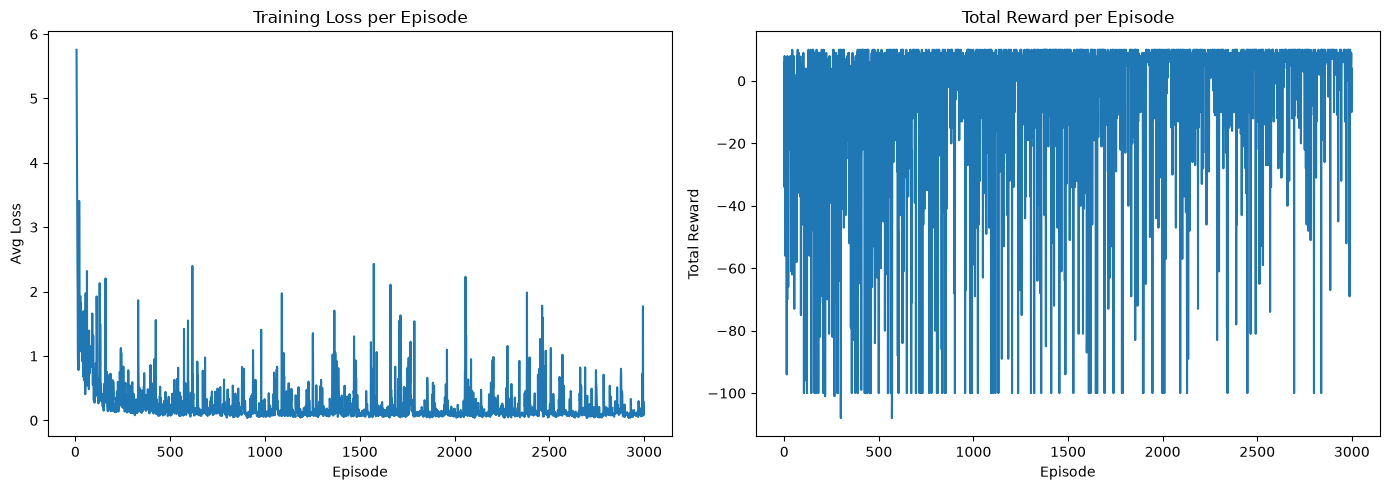

In [83]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(losses)
axes[0].set_title("Training Loss per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg Loss")


axes[1].plot(stats_rewards_list)
axes[1].set_title("Total Reward per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward")

plt.tight_layout()
plt.show()

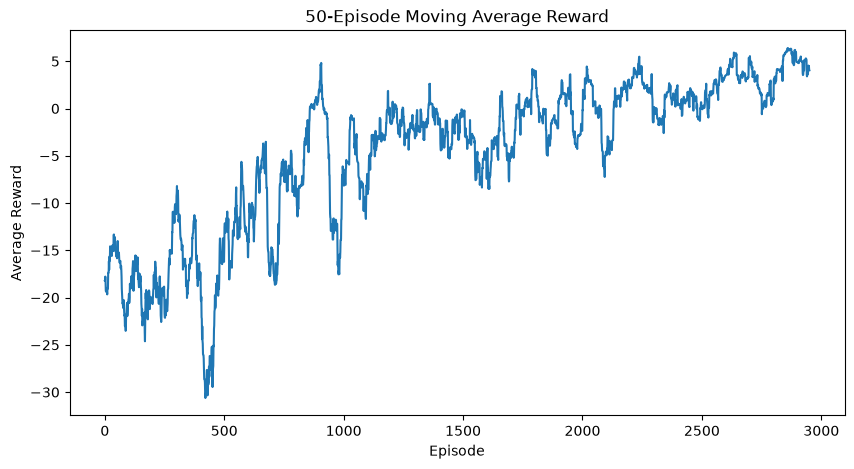

In [84]:
window = 50

reward_moving_avg = np.convolve(
    stats_rewards_list,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(reward_moving_avg)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("50-Episode Moving Average Reward")

plt.show()

In [85]:
gamma = 0.9

epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay_rate = 5000

num_episodes = 3000
max_steps = 100

lr = 5e-4
batch_size = 128
update_rate = 500

mem_size = 5000 

in_dim = 4 * 4 * 4
out_dim = 4
h_dim = 150

agent = GridWorldAgent(
    in_dim,
    out_dim,
    h_dim,
    lr,
    mem_size
)

losses = []
stats_rewards_list = []

num_iter = 0


for ep in range(num_episodes):

    env = Gridworld(size=4, mode='random')

    
    state_ = (
        env.board.render_np().reshape(-1, 64)
        + np.random.rand(1, 64) / 10.0
    )

    state = torch.from_numpy(state_).float()

    episode_loss = []
    total_reward = 0

    
    for step in range(max_steps):
        epsilon = epsilon_min + (
            epsilon_start - epsilon_min
        ) * np.exp(-num_iter / epsilon_decay_rate)

    
        action = agent.select_action(
            state,
            epsilon
        )

        env.makeMove(
            agent.ACTION_SET[action]
        )

    
        next_state_ = (
            env.board.render_np().reshape(-1, 64)
            + np.random.rand(1, 64) / 10.0
        )

        next_state = torch.from_numpy(
            next_state_
        ).float()

        
        reward = env.reward()

       
        done = 1 if reward != -1 else 0

       
        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        
        state = next_state

        total_reward += reward

       
        loss = agent.train(
            gamma,
            batch_size
        )

        if loss is not None:

            episode_loss.append(loss)

            if num_iter % 10 == 0:

                print(
                    f"Episode {ep:4d} | "
                    f"Step {step:3d} | "
                    f"Iter {num_iter:6d} | "
                    f"Loss: {loss:.4f} | "
                    f"Epsilon: {epsilon:.3f}"
                )

       
        agent.update_target_network(
            num_iter,
            update_rate
        )

        num_iter += 1

       
        if done:
            break

    losses.append(
        np.mean(episode_loss)
        if episode_loss
        else np.nan
    )

    stats_rewards_list.append(
        total_reward
    )

Episode    4 | Step   2 | Iter    130 | Loss: 3.9809 | Epsilon: 0.977
Episode    4 | Step  12 | Iter    140 | Loss: 3.7794 | Epsilon: 0.975
Episode    4 | Step  22 | Iter    150 | Loss: 3.5468 | Epsilon: 0.973
Episode    5 | Step   2 | Iter    160 | Loss: 4.0303 | Epsilon: 0.972
Episode    5 | Step  12 | Iter    170 | Loss: 2.2900 | Epsilon: 0.970
Episode    5 | Step  22 | Iter    180 | Loss: 2.0754 | Epsilon: 0.968
Episode    6 | Step   7 | Iter    190 | Loss: 2.7856 | Epsilon: 0.966
Episode    7 | Step   3 | Iter    200 | Loss: 3.9238 | Epsilon: 0.965
Episode    8 | Step   4 | Iter    210 | Loss: 3.2284 | Epsilon: 0.963
Episode    8 | Step  14 | Iter    220 | Loss: 2.6537 | Epsilon: 0.961
Episode    8 | Step  24 | Iter    230 | Loss: 2.9706 | Epsilon: 0.960
Episode    8 | Step  34 | Iter    240 | Loss: 1.3241 | Epsilon: 0.958
Episode    8 | Step  44 | Iter    250 | Loss: 2.1620 | Epsilon: 0.956
Episode    8 | Step  54 | Iter    260 | Loss: 1.5149 | Epsilon: 0.954
Episode   10 | Step 

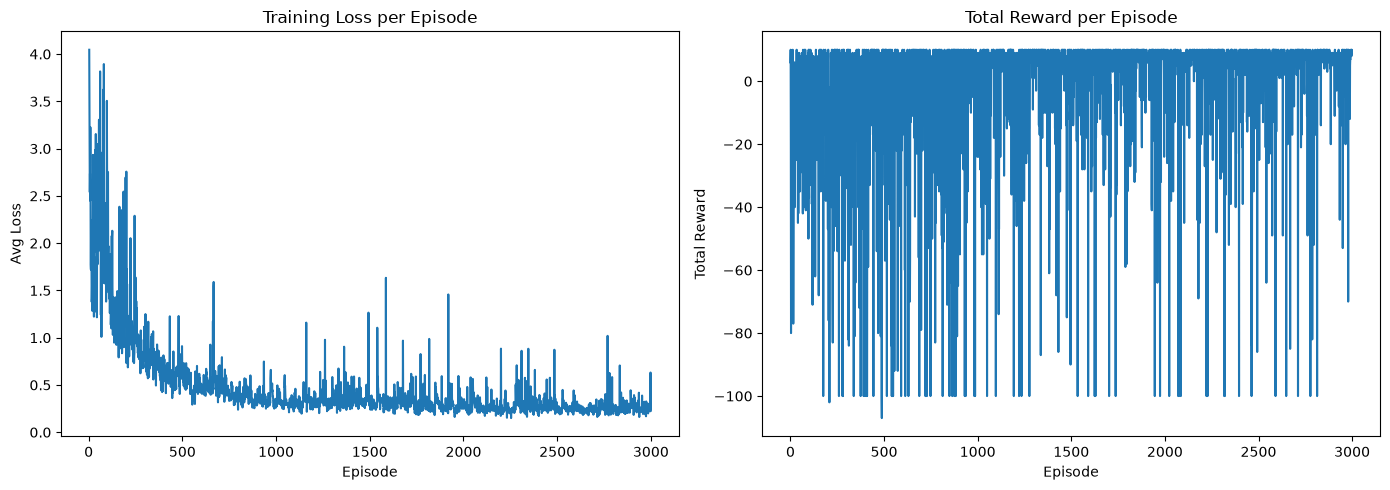

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(losses)
axes[0].set_title("Training Loss per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg Loss")


axes[1].plot(stats_rewards_list)
axes[1].set_title("Total Reward per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward")

plt.tight_layout()
plt.show()

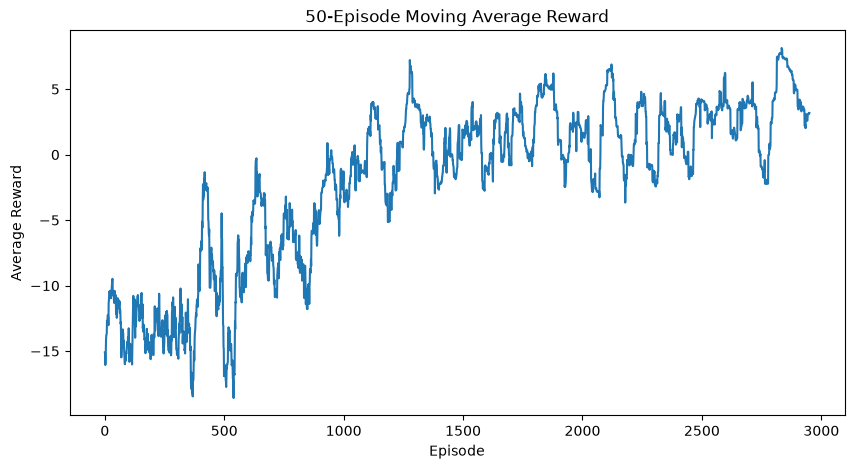

In [87]:
window = 50

reward_moving_avg = np.convolve(
    stats_rewards_list,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(reward_moving_avg)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("50-Episode Moving Average Reward")

plt.show()